In [1]:
import sleap
import sys
import cmath
import json
import os

sys.path.append('..')
from python.polygon_based_correction import *
from eval.eval import *
from python.dataset_conversion import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [17]:
training_json_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/models/250221_022817.centroid.n=4149/training_config.json'
# training_json_path = '/home/mingxiao/Desktop/jellyfish/label/models/250214_122024.single_instance.n=1653/training_config.json'
training_config = json.load(open(training_json_path))

In [19]:
val_indices = np.array(training_config['data']['labels']['validation_inds'])
train_indices = np.array(training_config['data']['labels']['training_inds'])
print(val_indices.shape)
print(train_indices.shape)

(415,)
(3734,)


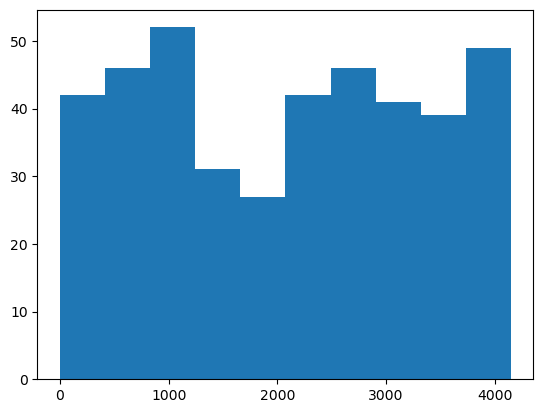

In [20]:
plt.hist(val_indices);

In [2]:
single_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels.v002.slp'
single_animal_dataset = sleap.load_file(single_animal_dataset_path)
print(single_animal_dataset)
multi_animal_dataset = single2multi(single_animal_dataset)
print(multi_animal_dataset)

Labels(labeled_frames=8089, videos=1, skeletons=1, tracks=0)
Tentacle count: 17
Average mouth location: [86.18999969 79.86647831]
Labels(labeled_frames=1653, videos=1, skeletons=1, tracks=17)


In [4]:
single_animal_dataset.skeleton

Skeleton(name='Skeleton-1', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [3]:
src_multi_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
src_multi_animal_dataset = sleap.load_file(src_multi_animal_dataset_path)
print(src_multi_animal_dataset)
src_single_animal_dataset = multi2single(src_multi_animal_dataset)
print(src_single_animal_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
Tentacle count: 17
Labels(labeled_frames=5202, videos=1, skeletons=1, tracks=0)


In [5]:
src_single_animal_dataset.skeleton

Skeleton(name='jellyfish', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [9]:
multi_v11_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v11.slp'
multi_v11_dataset = sleap.load_file(multi_v11_dataset_path)
print(multi_v11_dataset)

Labels(labeled_frames=4149, videos=1, skeletons=1, tracks=17)


In [18]:
single_v10_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels_v11.slp'
single_v10_dataset = multi2single(multi_v11_dataset, save_path=single_v10_dataset_path)
print(single_v10_dataset)

Tentacle count: 17
Labels(labeled_frames=4144, videos=1, skeletons=1, tracks=0)


(9000, 17, 2)
total_range_length: 4264


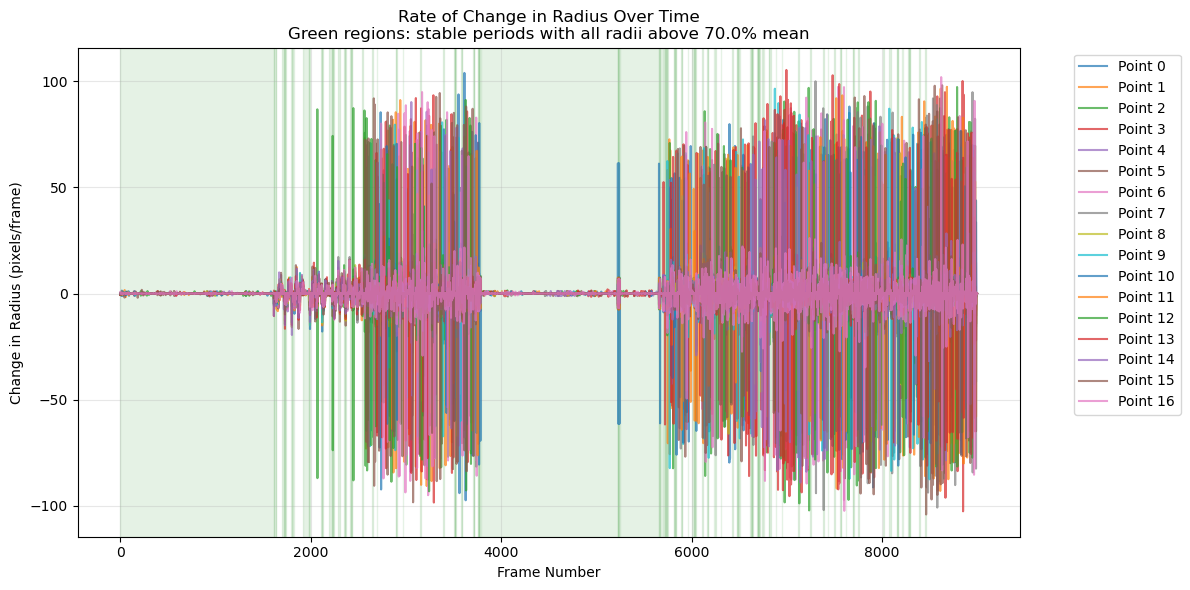

100%|██████████| 9000/9000 [00:04<00:00, 2023.11it/s]


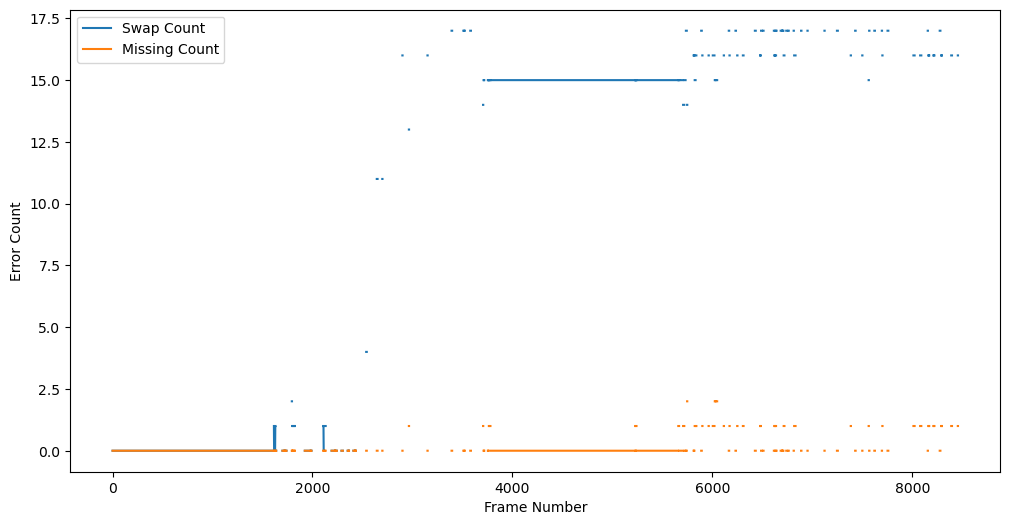

In [11]:
tracked_pts_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0_tracked_points.npy'
tracked_points = np.load(tracked_pts_path)
print(tracked_points.shape)
eval_dataset_from_points(tracked_points);